# Filter Experiment Analysis

This notebook analyzes the results of the filter and binarization experiment. We compare different filter types based on MSE, Dice Coefficient, and IoU scores.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load results
try:
    df = pd.read_csv("experiment_results.csv")
    print(f"Loaded {len(df)} records.")
except FileNotFoundError:
    print("Error")

Loaded 32275 records.


## 1. Summary Statistics

Calculate the mean and standard deviation for each metric grouped by filter type.

In [2]:
summary = df.groupby("filter_type")[["mse", "dice", "iou"]].agg(["mean", "std"])
summary.columns = [f"{col[0]}_{col[1]}" for col in summary.columns]
summary = summary.reset_index()
display(summary.sort_values(by="dice_mean", ascending=False))

,filter_type,mse_mean,mse_std,dice_mean,dice_std,iou_mean,iou_std
0,bilateral,0.126507,0.121543,0.554319,0.277627,0.428865,0.273458
3,median,0.128206,0.115959,0.533463,0.274998,0.406383,0.266565
1,blur,0.128526,0.117069,0.517458,0.282568,0.393536,0.272729
4,none,0.172806,0.117103,0.449887,0.239583,0.317809,0.215062
2,gaussian,0.247427,0.227714,0.038575,0.192594,0.038575,0.192594


In [11]:
print(summary[["filter_type", "mse_mean", "mse_std"]])

  filter_type  mse_mean   mse_std
0   bilateral  0.126507  0.121543
1        blur  0.128526  0.117069
2    gaussian  0.247427  0.227714
3      median  0.128206  0.115959
4        none  0.172806  0.117103


## 2. Visual Comparison of Metrics

Higher Dice and IoU are better, while lower MSE is better.

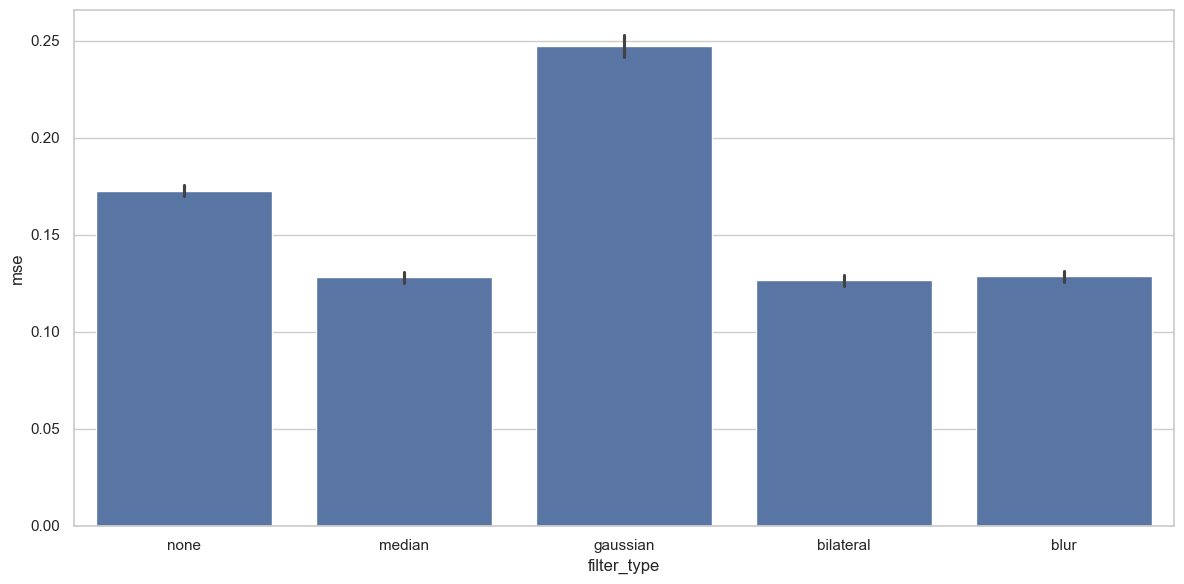

In [3]:
sns.barplot(data=df, x="filter_type", y="mse")

plt.tight_layout()
plt.show()

## 3. Score Distribution

Boxplots show the distribution of scores. A smaller box indicates that the filter performs consistently across the entire dataset.

/var/folders/y7/h9b651_1543gvb5qx83kjqg40000gn/T/ipykernel_12225/398041889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="filter_type", y="mse", palette="Set2")


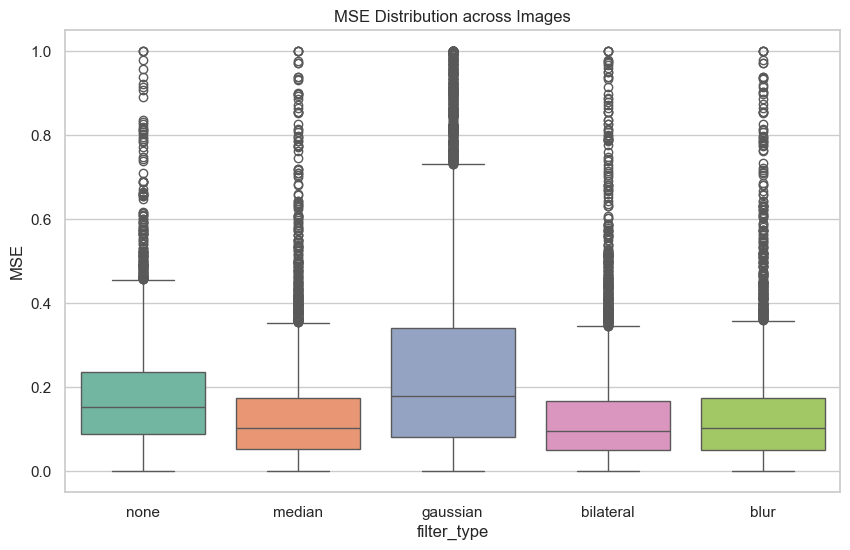

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="filter_type", y="mse", palette="Set2")
plt.title("MSE Distribution across Images")
plt.ylabel("MSE")
plt.show()

## 4. Identifying the Best and Worst Performers

Which specific images were most difficult for the best filter.

In [6]:
best_filter = summary.loc[summary["dice_mean"].idxmax(), "filter_type"]
print(f"The best performing filter overall is: {best_filter.upper()}")

best_filter_data = df[df["filter_type"] == best_filter]
worst_images = best_filter_data.sort_values(by="dice").head(5)

print(f"\nTop 5 most difficult images for {best_filter}:")
display(worst_images[["image_name", "dice", "mse"]])

The best performing filter overall is: BILATERAL

Top 5 most difficult images for bilateral:


,image_name,dice,mse
22276,palsar_828.png,0.0,0.003128
22199,palsar_759.png,0.0,0.029724
25691,sentinel_883.png,0.0,0.000809
25083,sentinel_3353.png,0.0,0.252563
21983,palsar_564.png,0.0,0.066163


## 5. Threshold Analysis

Threshold values and inversion settings found to be optimal for each filter type.

,filter_type,threshold,inverse
0,bilateral,67,True
1,blur,62,True
2,gaussian,254,False
3,median,62,True
4,none,56,True


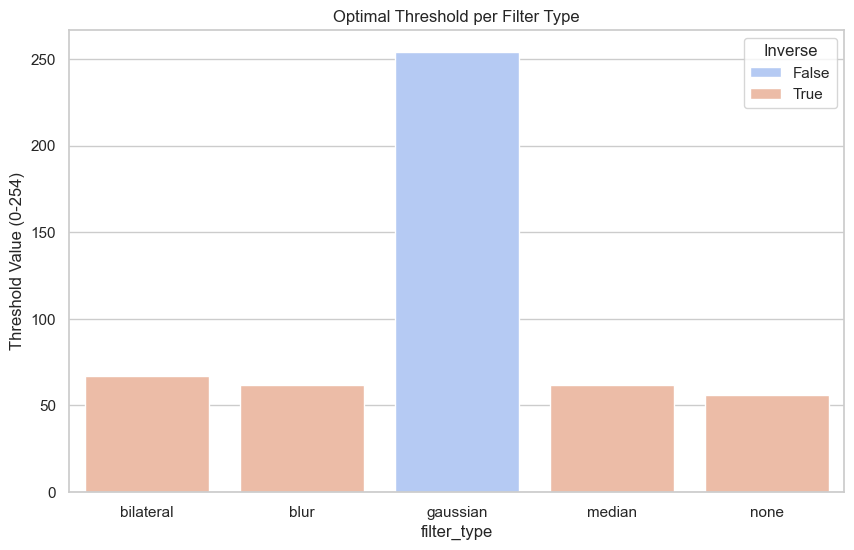

In [7]:
threshold_summary = df.groupby("filter_type")[["threshold", "inverse"]].first().reset_index()
display(threshold_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=threshold_summary, x="filter_type", y="threshold", hue="inverse", palette="coolwarm")
plt.title("Optimal Threshold per Filter Type")
plt.ylabel("Threshold Value (0-254)")
plt.legend(title="Inverse", loc='upper right')
plt.show()

In [13]:
print(threshold_summary)

  filter_type  threshold  inverse
0   bilateral         67     True
1        blur         62     True
2    gaussian        254    False
3      median         62     True
4        none         56     True
